# Clasificación de flores Iris

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

In [2]:
iris = datasets.load_iris()

In [ ]:
iris

In [4]:
# Sólo dos características tomaremos (largo y ancho de los pétalos)

X = iris.data[:, : 2]
Y = iris.target

In [5]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

In [6]:
h = (x_max - x_min) / 100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

X_plot = np.c_[xx.ravel(), yy.ravel()]

In [7]:
svc = svm.SVC(kernel = 'linear', C = 1.0, decision_function_shape = 'ovr').fit(X, Y)
Ypred = svc.predict(X_plot)
Ypred = Ypred.reshape(xx.shape)

Text(0.5, 1.0, 'SVC para las flores del Iris con kernel lineal')

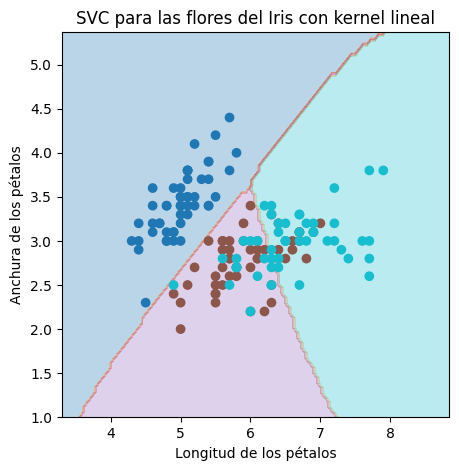

In [10]:
plt.figure(figsize = (5, 5))
plt.contourf(xx, yy, Ypred, cmap = plt.cm.tab10, alpha = 0.3)
plt.scatter(X[:, 0], X[:, 1], c = Y, cmap = plt.cm.tab10)
plt.xlabel('Longitud de los pétalos')
plt.ylabel('Anchura de los pétalos')
plt.title('SVC para las flores del Iris con kernel lineal')

In [11]:
svc = svm.SVC(kernel = 'rbf', C = 1.0, decision_function_shape = 'ovr').fit(X, Y)
Ypred = svc.predict(X_plot)
Ypred = Ypred.reshape(xx.shape)

Text(0.5, 1.0, 'SVC para las flores del Iris con kernel RBF')

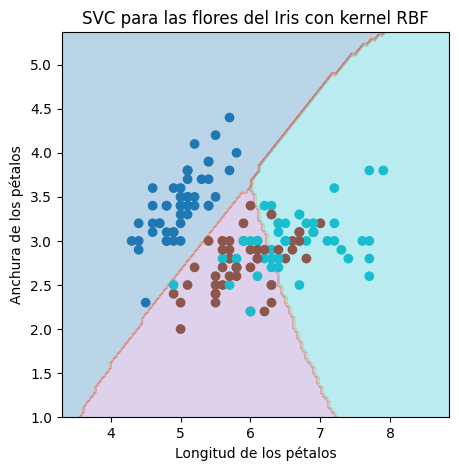

In [25]:
plt.figure(figsize = (5, 5))
plt.contourf(xx, yy, Ypred, cmap = plt.cm.tab10, alpha = 0.3)
plt.scatter(X[:, 0], X[:, 1], c = Y, cmap = plt.cm.tab10)
plt.xlabel('Longitud de los pétalos')
plt.ylabel('Anchura de los pétalos')
plt.title('SVC para las flores del Iris con kernel RBF')

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.utils import shuffle

In [14]:
X, Y = shuffle(X, Y)

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [16]:
# Lista de diccionarios:

parameters = [
    {
        'kernel': ['linear'],
        'C': [1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [1, 10, 100, 1000],
        'gamma': [1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.5]
    }
]

In [17]:
clf = GridSearchCV(svm.SVC(decision_function_shape = 'ovr'), param_grid = parameters, cv = 5)

In [18]:
clf.fit(X, Y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000],
                          'gamma': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.5],
                          'kernel': ['rbf']}])

In [19]:
clf.best_params_

{'C': 1, 'gamma': 0.2, 'kernel': 'rbf'}

In [20]:
ypred = clf.predict(X_test)

In [21]:
print(classification_report(Y_test, ypred, target_names = ['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.80      0.92      0.86        13
   virginica       0.90      0.75      0.82        12

    accuracy                           0.89        38
   macro avg       0.90      0.89      0.89        38
weighted avg       0.90      0.89      0.89        38



# Resumen:

### Podemos crear una función:

In [22]:
def svm_iris(C = 1.0, gamma = 0.01, kernel = 'rbf'):

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn import svm, datasets

    iris = datasets.load_iris()

    X = iris.data[:, : 2]
    Y = iris.target

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    h = (x_max - x_min) / 100

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    X_plot = np.c_[xx.ravel(), yy.ravel()]

    # Notar en la línea siguiente que se añade el parámetro "gamma":

    svc = svm.SVC(kernel = kernel, C = C, gamma = gamma, decision_function_shape = 'ovr').fit(X, Y)
    Ypred = svc.predict(X_plot)
    Ypred = Ypred.reshape(xx.shape)

    plt.figure(figsize = (5, 5))
    plt.contourf(xx, yy, Ypred, cmap = plt.cm.tab10, alpha = 0.3)
    plt.scatter(X[:, 0], X[:, 1], c = Y, cmap = plt.cm.tab10)
    plt.xlabel('Longitud de los pétalos')
    plt.ylabel('Anchura de los pétalos')
    plt.title('SVC para las flores del Iris con kernel {}'.format(kernel))

In [23]:
from ipywidgets import interact, fixed

interactive(children=(Dropdown(description='C', index=2, options=(0.01, 0.1, 1, 10, 100, 1000, 1000000.0, 1000…

<function __main__.svm_iris(C=1.0, gamma=0.01, kernel='rbf')>

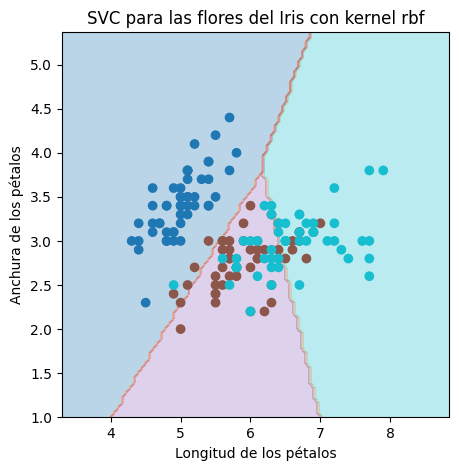

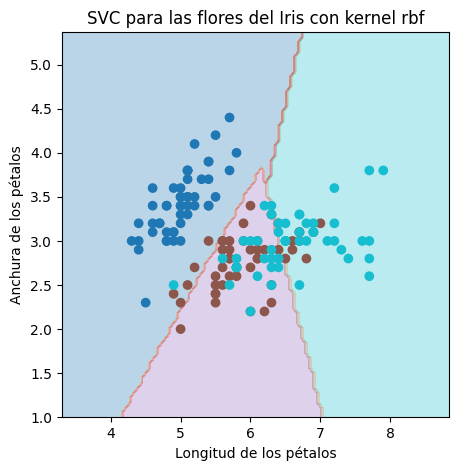

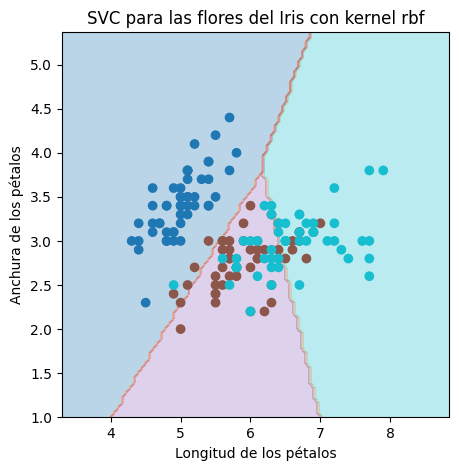

In [24]:
interact(svm_iris, C = [0.01, 0.1, 1, 10, 100, 1000, 1e6, 1e10],
         gamma = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.5, 0.99],
         kernel = ['linear', 'rbf', 'poly', 'sigmoid'])